 # Hydrogeological EDA – Aquifer Water Level Analysis



 This notebook performs a complete exploratory data analysis (EDA) for:



 - Groundwater level (piezometric level)

 - Rainfall

 - Atmospheric pressure

 - Pumping well operational status

 - Earth tide (solid Earth tide components)



 Objectives:



 1. Assess data quality and consistency

 2. Understand statistical properties and distributions

 3. Explore temporal patterns (trend, seasonality, autocorrelation)

 4. Investigate hydrogeological relationships among variables

 5. Support the development of robust forecasting models (ML / DL)

 ## 0. Imports and Initial Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Time series tools
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)



 ## 1. Load and Integrate Data



 Expected files (under `BASE_PATH`):



 - `nivel-pocos_chuva_pressao_tratados.csv`

 - `funcionamento_pocos_30min.csv`

 - `earth_tide.csv`

In [16]:
BASE_PATH = "."

path_level_rain_pressure = os.path.join(BASE_PATH, "data/nivel-pocos_chuva_pressao_tratados.csv")
path_wells_func = os.path.join(BASE_PATH, "data/funcionamento_pocos_30min.csv")
path_earth_tide = os.path.join(BASE_PATH, "data/earth_tide.csv")

# Load datasets
level_rain_pressure = pd.read_csv(path_level_rain_pressure)
wells_func = pd.read_csv(path_wells_func, sep=",")
earth_tide = pd.read_csv(path_earth_tide)

# Standardize time column
if "datetime" in earth_tide.columns:
    earth_tide = earth_tide.rename(columns={"datetime": "date_time"})

# Validate time column existence
for df in [level_rain_pressure, wells_func, earth_tide]:
    if "date_time" not in df.columns:
        raise ValueError("Dataset missing 'date_time' column.")

# Convert pumping well status columns to integers
wells_func = wells_func.dropna()
cols_func = wells_func.columns.difference(["date_time"])
wells_func[cols_func] = wells_func[cols_func].astype(int)

# Merge all dataframes
data = (
    level_rain_pressure
    .merge(wells_func, on="date_time", how="outer")
    .merge(earth_tide, on="date_time", how="outer")
)

# Convert time and sort chronologically
data["date_time"] = pd.to_datetime(data["date_time"])
data = data.sort_values("date_time").reset_index(drop=True)

print("Final merged dataset shape:", data.shape)
data.head()



Final merged dataset shape: (70080, 8)


,date_time,pressao_mH2O_final,gmu_level_mH2O_compensado,chuva_mm_30min,status_IMECC,status_FEF,status_ZOOLOGIA,earth_tide_nm/s2
0,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-5.263
1,2022-01-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,-161.201
2,2022-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-279.700
3,2022-01-01 01:30:00,NaN,NaN,NaN,NaN,NaN,NaN,-351.661
4,2022-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-371.415


In [17]:
summary = []

for col in data.columns:
    if col == "date_time":
        continue

    mask = data[col].notna()

    if mask.any():
        times = data.loc[mask, "date_time"]
        summary.append({
            "column": col,
            "first_valid_date_time": times.iloc[times.values.argmin()],
            "last_valid_date_time": times.iloc[times.values.argmax()],
            "n_valid": mask.sum()
        })

summary_df = pd.DataFrame(summary).sort_values("first_valid_date_time")
summary_df

,column,first_valid_date_time,last_valid_date_time,n_valid
6,earth_tide_nm/s2,2022-01-01 00:00:00,2025-12-30 23:30:00,70080
3,status_IMECC,2022-01-01 07:00:00,2025-08-30 14:00:00,64191
4,status_FEF,2022-01-01 07:00:00,2025-08-30 14:00:00,64191
5,status_ZOOLOGIA,2022-01-01 07:00:00,2025-08-30 14:00:00,64191
0,pressao_mH2O_final,2022-04-18 00:00:00,2025-08-14 16:00:00,58305
2,chuva_mm_30min,2022-04-18 00:00:00,2025-08-14 16:00:00,58305
1,gmu_level_mH2O_compensado,2022-04-19 11:00:00,2025-08-14 16:00:00,36717


In [18]:
import pandas as pd
import numpy as np

col = "gmu_level_mH2O_compensado"

# seleciona apenas linhas com dado válido
df_valid = data.loc[data[col].notna(), ["date_time"]].copy()

# calcula diferença temporal entre observações consecutivas
dt = df_valid["date_time"].diff()

# passo temporal dominante (robusto)
dt_ref = dt.mode().iloc[0]

# define quebra de continuidade (ex: > 2× o passo dominante)
gap_threshold = 2 * dt_ref

# identifica início de novo período
new_period = (dt.isna()) | (dt > gap_threshold)

# numera os períodos
df_valid["period_id"] = new_period.cumsum()

# resume cada período contínuo
periods = (
    df_valid
    .groupby("period_id")
    .agg(
        start=("date_time", "min"),
        end=("date_time", "max"),
        n_obs=("date_time", "count")
    )
    .reset_index(drop=True)
)

# duração em dias
periods["duration_days"] = (
    periods["end"] - periods["start"]
).dt.total_seconds() / 86400

periods


,start,end,n_obs,duration_days
0,2022-04-19 11:00:00,2022-04-29 09:00:00,477,9.916667
1,2022-05-11 15:30:00,2022-07-11 11:00:00,2920,60.812500
2,2022-07-18 11:00:00,2022-09-13 16:00:00,2747,57.208333
3,2022-09-14 16:30:00,2022-09-27 16:00:00,624,12.979167
4,2022-10-06 15:30:00,2022-10-17 15:30:00,529,11.000000
5,2022-10-20 16:00:00,2022-10-25 07:00:00,223,4.625000
6,2022-11-03 15:00:00,2022-12-01 15:00:00,1345,28.000000
7,2022-12-15 16:30:00,2023-01-18 15:00:00,1630,33.937500
8,2023-02-07 18:00:00,2023-02-09 09:00:00,79,1.625000
9,2023-02-09 15:30:00,2023-02-24 15:30:00,721,15.000000


 ## 1.1 Data Period Selection



 Define the time window to be used for the entire notebook.

 All subsequent analyses will be performed only on this filtered date range.

In [19]:
# ---------------------------------------
# 1.1 Select Data Period
# ---------------------------------------

# Define start and end date here
# Example:
# start_date = "2021-01-01"
# end_date   = "2022-01-01"

start_date = "2022-05-11 15:30:00"   # or None / "YYYY-MM-DD"
end_date = "2022-07-11 11:00:00"     # or None / "YYYY-MM-DD"

# Ensure datetime format
data["date_time"] = pd.to_datetime(data["date_time"])

# Apply filtering only if values are provided
filtered_data = data.copy()

if start_date is not None:
    filtered_data = filtered_data[filtered_data["date_time"] >= pd.to_datetime(start_date)]

if end_date is not None:
    filtered_data = filtered_data[filtered_data["date_time"] <= pd.to_datetime(end_date)]

# Create the time-indexed version, filtered
data_ts = filtered_data.set_index("date_time").sort_index()

print("Selected date range:")
print(f"  Start: {data_ts.index.min()}")
print(f"  End:   {data_ts.index.max()}")
print(f"Filtered dataset shape: {filtered_data.shape}")

data_ts.tail()



Selected date range:
  Start: 2022-05-11 15:30:00
  End:   2022-07-11 11:00:00
Filtered dataset shape: (2920, 8)


,pressao_mH2O_final,gmu_level_mH2O_compensado,chuva_mm_30min,status_IMECC,status_FEF,status_ZOOLOGIA,earth_tide_nm/s2
date_time,,,,,,,
2022-07-11 09:00:00,9.662643,22.129557,0.0,1.0,1.0,1.0,813.031
2022-07-11 09:30:00,9.664400,22.126200,0.0,1.0,1.0,1.0,703.660
2022-07-11 10:00:00,9.664963,22.130737,0.0,1.0,1.0,1.0,561.712
2022-07-11 10:30:00,9.661518,22.136082,0.0,1.0,1.0,1.0,399.732
2022-07-11 11:00:00,9.659268,22.136132,0.0,1.0,1.0,1.0,231.171


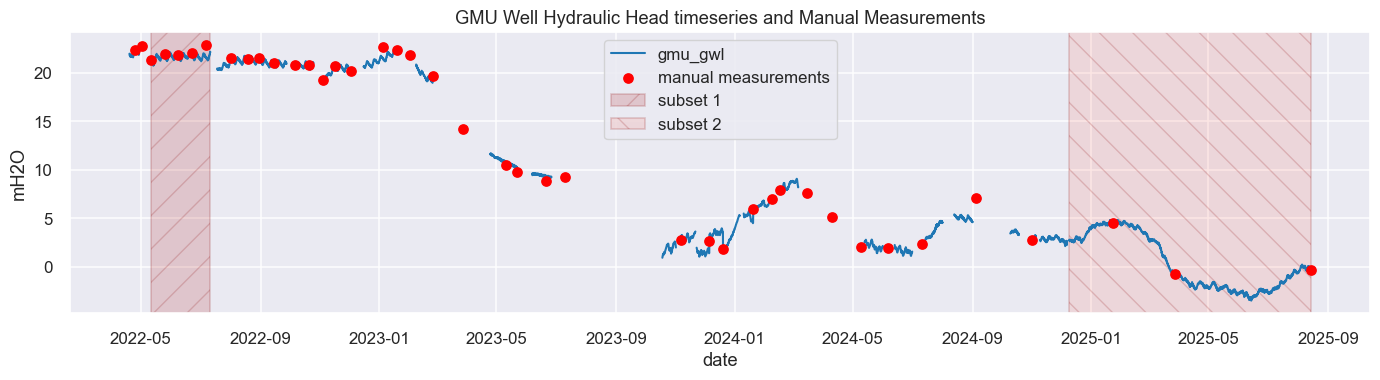

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# ----------------------------
# Load manual reference points
# ----------------------------
path_pontos_manuais = os.path.join(BASE_PATH, "data/pontos_manuais_cota_offset.csv")
pontos_manuais = pd.read_csv(path_pontos_manuais)
pontos_manuais["data"] = pd.to_datetime(pontos_manuais["data"])

# ----------------------------
# Hydraulic head time series
# ----------------------------
series = filtered_data.set_index("date_time")["gmu_level_mH2O_compensado"]

series_valid = series.dropna()
t = series_valid.index
y = series_valid.values

# ----------------------------
# Gap handling (visual break)
# ----------------------------
dt_hours = t.to_series().diff().dt.total_seconds() / 3600
gap_threshold_hours = 6
gap_idx = np.where(dt_hours > gap_threshold_hours)[0]

y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# ----------------------------
# Filter manual points to visible range
# ----------------------------
pontos_manuais = pontos_manuais[
    (pontos_manuais["data"] >= t.min()) &
    (pontos_manuais["data"] <= t.max())
]

# ----------------------------
# Define subsets
# ----------------------------
subset1_start = pd.Timestamp("2022-05-11 15:30:00")
subset1_end   = pd.Timestamp("2022-07-11 11:00:00")

subset2_start = pd.Timestamp("2024-12-08 23:00:00")
subset2_end   = pd.Timestamp("2025-08-14 16:00:00")

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(14, 4))

# Hydraulic head
ax.plot(
    t,
    y_plot,
    color="tab:blue",
    linewidth=1.5,
    label="gmu_gwl"
)

# Manual measurements
ax.scatter(
    pontos_manuais["data"],
    pontos_manuais["valor_equivalente"],
    color="red",
    s=45,
    zorder=5,
    label="manual measurements"
)

# Subset rectangles — more distinguishable
ax.axvspan(
    subset1_start,
    subset1_end,
    facecolor="firebrick",
    edgecolor="darkred",
    alpha=0.18,
    hatch="/",
    linewidth=1.2,
    label="subset 1"
)

ax.axvspan(
    subset2_start,
    subset2_end,
    facecolor="salmon",
    edgecolor="darkred",
    alpha=0.18,
    hatch="\\",
    linewidth=1.2,
    label="subset 2"
)

# Formatting
ax.set_title("GMU Well Hydraulic Head timeseries and Manual Measurements")
ax.set_ylabel("mH2O")
ax.set_xlabel("date")
ax.grid(
    which="major",
    linestyle="-",
    linewidth=1.5,
    alpha=0.7
)

# Legend (avoid duplicate labels)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=True)

plt.tight_layout()
plt.show()


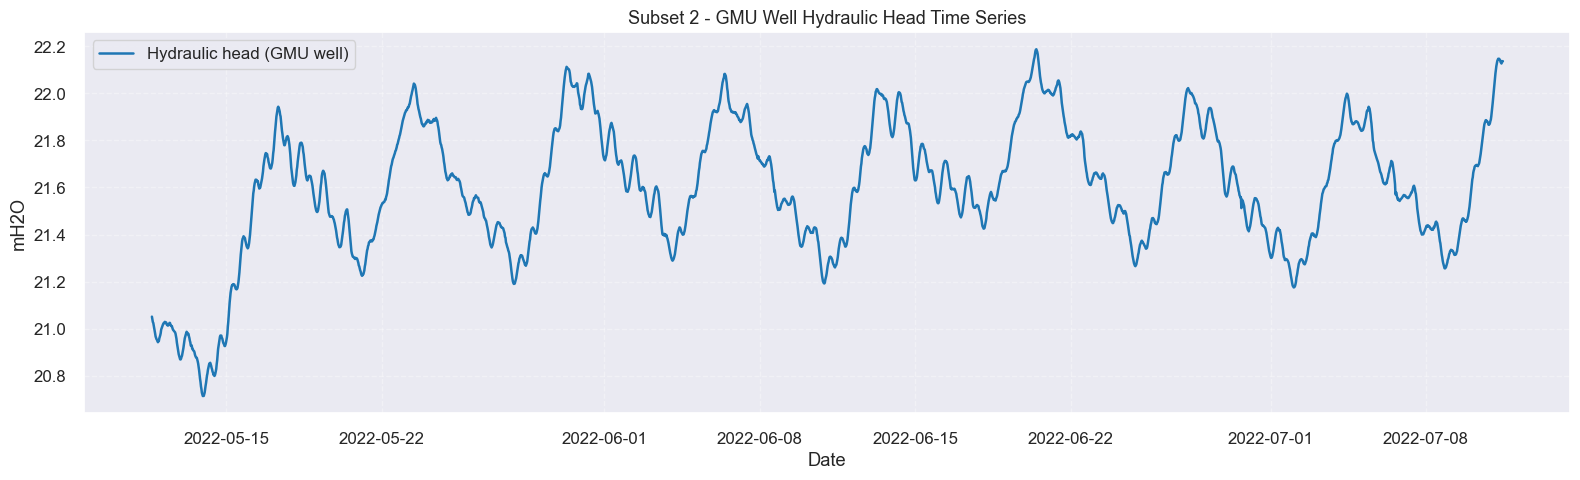

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# Groundwater level time series
# ============================
series = filtered_data.set_index("date_time")["gmu_level_mH2O_compensado"]

# keep only valid values
series_valid = series.dropna()
t = series_valid.index
y = series_valid.values

# ----------------------------
# Gap handling (6 hours)
# ----------------------------
dt_hours = t.to_series().diff().dt.total_seconds() / 3600
gap_threshold_hours = 6
gap_idx = np.where(dt_hours > gap_threshold_hours)[0]

# force visual break at gaps
y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# ============================
# Plot
# ============================
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    t,
    y_plot,
    color="tab:blue",
    linewidth=1.8,
    label="Hydraulic head (GMU well)"
)

ax.set_title("Subset 2 - GMU Well Hydraulic Head Time Series", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("mH2O")

ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()


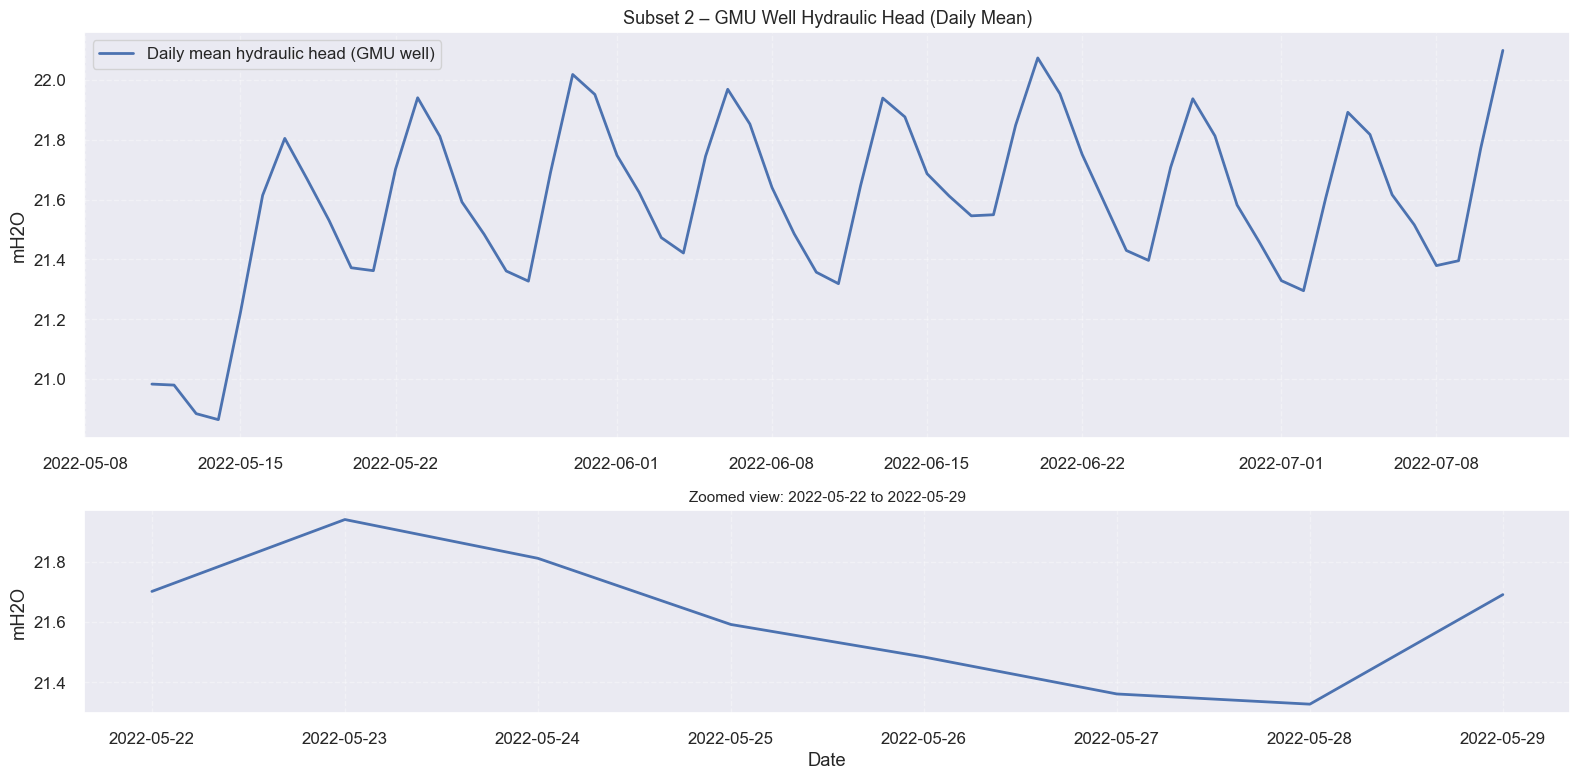

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# USER-DEFINED ZOOM INTERVAL
# ============================
zoom_start = "2022-05-22"
zoom_end   = "2022-05-29"

# ============================
# Groundwater level time series
# ============================
series = filtered_data.set_index("date_time")["gmu_level_mH2O_compensado"]

# keep only valid values
series_valid = series.dropna()

# ============================
# Daily aggregation (mean)
# ============================
series_daily = series_valid.resample("D").mean()

t = series_daily.index
y = series_daily.values

# ----------------------------
# Gap handling (days)
# ----------------------------
dt_days = t.to_series().diff().dt.total_seconds() / (3600 * 24)
gap_threshold_days = 1.5
gap_idx = np.where(dt_days > gap_threshold_days)[0]

# force visual break at gaps
y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# ============================
# Zoomed subset (week)
# ============================
series_zoom = series_daily.loc[zoom_start:zoom_end]

t_zoom = series_zoom.index
y_zoom = series_zoom.values

# ============================
# Plot
# ============================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(16, 8),
    sharex=False,
    gridspec_kw={"height_ratios": [2, 1]}
)

# ---- Full period ----
ax1.plot(
    t,
    y_plot,
    linewidth=2.0,
    label="Daily mean hydraulic head (GMU well)"
)

ax1.set_title("Subset 2 – GMU Well Hydraulic Head (Daily Mean)", fontsize=13)
ax1.set_ylabel("mH2O")
ax1.grid(True, linestyle="--", alpha=0.35)
ax1.legend(frameon=True)

# ---- Zoomed week ----
ax2.plot(
    t_zoom,
    y_zoom,
    linewidth=2.0
)

ax2.set_title(f"Zoomed view: {zoom_start} to {zoom_end}", fontsize=11)
ax2.set_xlabel("Date")
ax2.set_ylabel("mH2O")
ax2.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


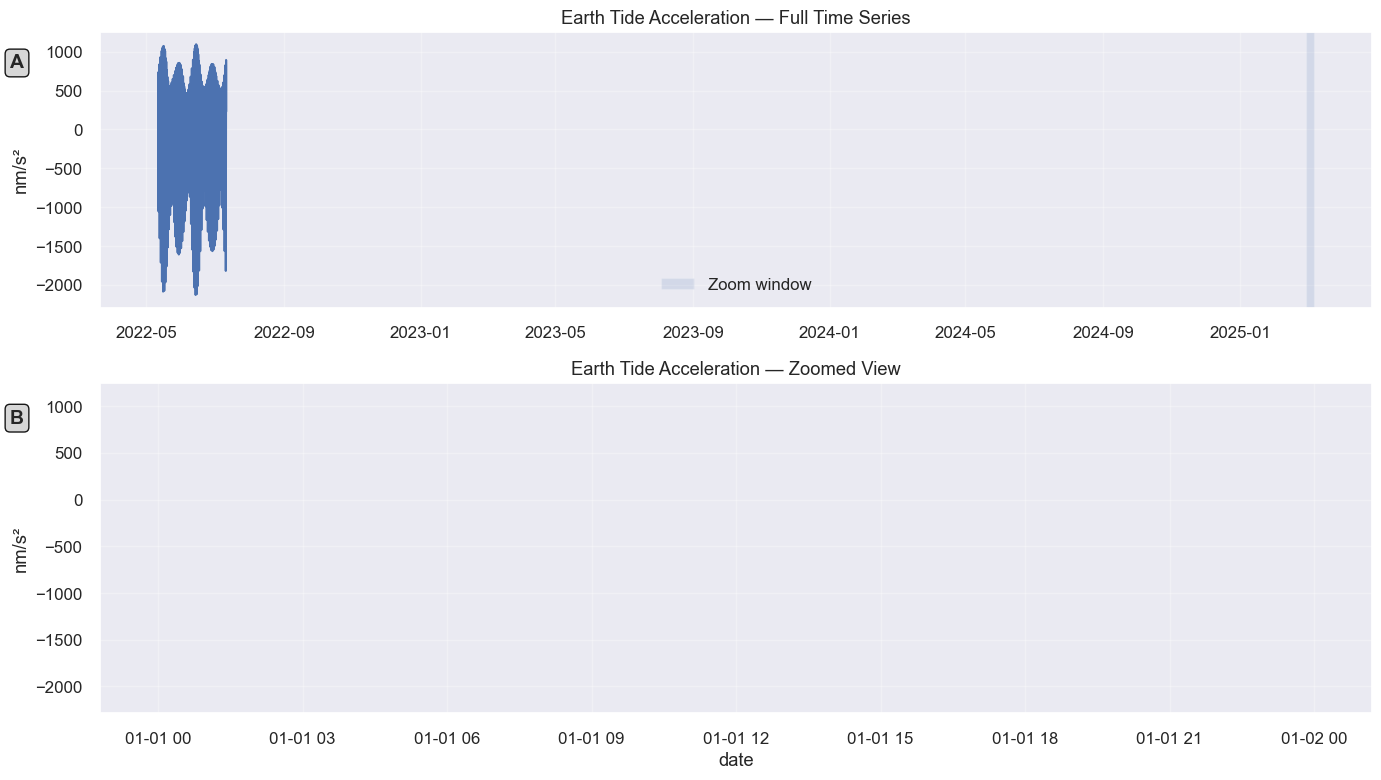

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Time series
# ----------------------------
series = filtered_data.set_index("date_time")["earth_tide_nm/s2"]

# 1) keep only valid values
series_valid = series.dropna()

t = series_valid.index
y = series_valid.values

# 2) temporal difference in hours
dt_hours = t.to_series().diff().dt.total_seconds() / 3600

# 3) gap threshold
gap_threshold_hours = 6
gap_idx = np.where(dt_hours > gap_threshold_hours)[0]

# 4) force visual break
y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# ----------------------------
# Define zoom window
# ----------------------------
zoom_start = pd.Timestamp("2025-03-01")
zoom_end   = pd.Timestamp("2025-03-08")

zoom_mask = (t >= zoom_start) & (t <= zoom_end)

# ----------------------------
# Plot: full series + zoom
# ----------------------------
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 8),
    sharey=True,
    gridspec_kw={"height_ratios": [1, 1.2]}
)

# ---- Full series (A)
axes[0].plot(t, y_plot)
axes[0].set_title("Earth Tide Acceleration — Full Time Series")
axes[0].set_ylabel("nm/s²")
axes[0].grid(alpha=0.3)

axes[0].text(
    -0.06, 0.92, "A",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
    bbox=dict(
        facecolor="lightgray",
        edgecolor="black",
        boxstyle="round,pad=0.25",
        alpha=0.9
    )
)

# Highlight zoom window
axes[0].axvspan(
    zoom_start,
    zoom_end,
    alpha=0.15,
    label="Zoom window"
)
axes[0].legend()

# ---- Zoomed series (B)
axes[1].plot(
    t[zoom_mask],
    y_plot[zoom_mask]
)
axes[1].set_title("Earth Tide Acceleration — Zoomed View")
axes[1].set_ylabel("nm/s²")
axes[1].set_xlabel("date")
axes[1].grid(alpha=0.3)

axes[1].text(
    -0.06, 0.92, "B",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
    bbox=dict(
        facecolor="lightgray",
        edgecolor="black",
        boxstyle="round,pad=0.25",
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()


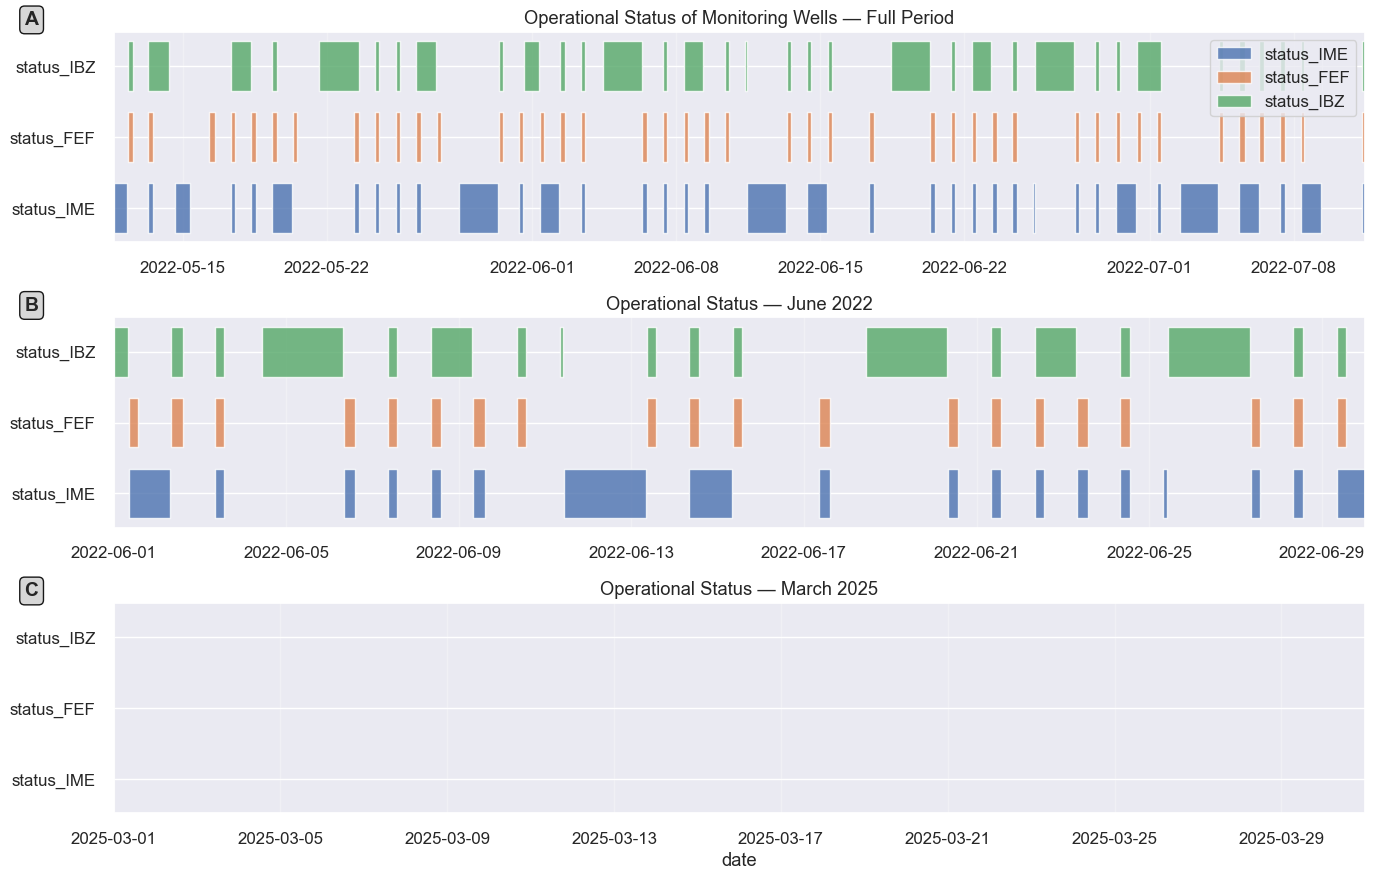

In [79]:
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Prepare data
# ----------------------------
df = filtered_data.copy()
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time")

status_cols = {
    "status_IMECC": "status_IME",
    "status_FEF": "status_FEF",
    "status_ZOOLOGIA": "status_IBZ"
}

t = df["date_time"]

# ----------------------------
# Define zoom windows (EDIT HERE)
# ----------------------------
# One month in 2022
zoom_2022_start = pd.Timestamp("2022-06-01")
zoom_2022_end   = pd.Timestamp("2022-06-30")

# One month in 2025
zoom_2025_start = pd.Timestamp("2025-03-01")
zoom_2025_end   = pd.Timestamp("2025-03-31")

# ----------------------------
# Plot: A (full), B (2022), C (2025)
# ----------------------------
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 9),
    sharey=True
)

panels = [
    ("A", t.min(), t.max(), "Operational Status of Monitoring Wells — Full Period"),
    ("B", zoom_2022_start, zoom_2022_end, "Operational Status — June 2022"),
    ("C", zoom_2025_start, zoom_2025_end, "Operational Status — March 2025")
]

for ax, (label_panel, t_start, t_end, title) in zip(axes, panels):

    mask = (t >= t_start) & (t <= t_end)

    for i, (col, label) in enumerate(status_cols.items()):
        status = df.loc[mask, col].fillna(0)

        ax.fill_between(
            t[mask],
            i - 0.35,
            i + 0.35,
            where=status == 1,
            step="post",
            alpha=0.8,
            label=label if ax == axes[0] else None
        )

    # Axis formatting
    ax.set_xlim(t_start, t_end)
    ax.set_yticks(range(len(status_cols)))
    ax.set_yticklabels(list(status_cols.values()))
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)

    # Panel label (A, B, C) with gray background
    ax.text(
        -0.06, 1.1, label_panel,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="right",
        bbox=dict(
            facecolor="lightgray",
            edgecolor="black",
            boxstyle="round,pad=0.25",
            alpha=0.9
        )
    )

# Common labels
axes[-1].set_xlabel("date")
axes[0].legend(loc="upper right", frameon=True)

plt.subplots_adjust(hspace=0.45)
plt.tight_layout()
plt.show()


C:\Users\peliz\AppData\Local\Temp\ipykernel_48604\757369451.py:129: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\peliz\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


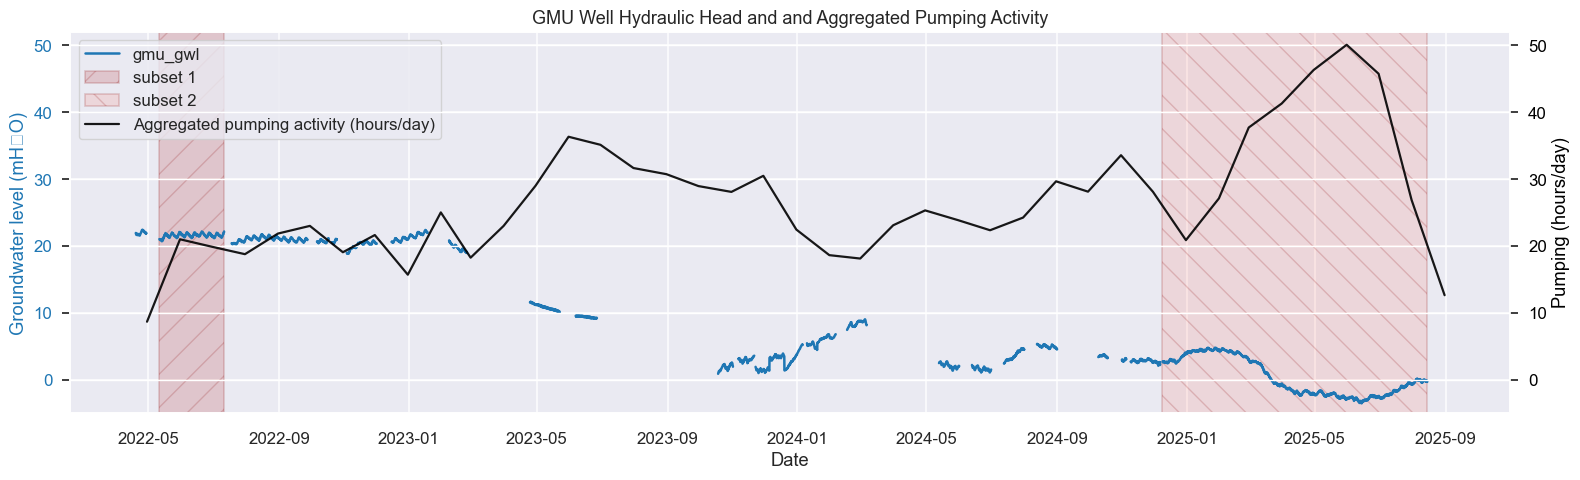

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# Groundwater level time series
# ============================
series = filtered_data.set_index("date_time")["gmu_level_mH2O_compensado"]

series_valid = series.dropna()
t = series_valid.index
y = series_valid.values

# Gap handling (6h)
dt_hours = t.to_series().diff().dt.total_seconds() / 3600
gap_threshold_hours = 6
gap_idx = np.where(dt_hours > gap_threshold_hours)[0]

y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# ============================
# Monthly pumping activity
# ============================
status_cols = ["status_IMECC", "status_FEF", "status_ZOOLOGIA"]
status_cols = [c for c in status_cols if c in filtered_data.columns]

df_status = filtered_data.set_index("date_time")[status_cols]

dt_step_hours = 0.5  # 30 min resolution

monthly_hours = df_status.resample("M").sum() * dt_step_hours
monthly_mean_hours = monthly_hours.div(
    monthly_hours.index.days_in_month, axis=0
)
monthly_hours_sum = monthly_mean_hours.sum(axis=1)

# ============================
# Define subsets
# ============================
subset1_start = pd.Timestamp("2022-05-11 15:30:00")
subset1_end   = pd.Timestamp("2022-07-11 11:00:00")

subset2_start = pd.Timestamp("2024-12-08 23:00:00")
subset2_end   = pd.Timestamp("2025-08-14 16:00:00")

# ============================
# Plot (dual y-axis + subsets)
# ============================
fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.set_axisbelow(True)  # grid below shaded areas

# Left axis: groundwater level
ax1.plot(
    t,
    y_plot,
    color="tab:blue",
    linewidth=1.8,
    label="gmu_gwl"
)
ax1.set_ylabel("Groundwater level (mH₂O)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(-5, 52)

# Subset rectangles (same style as reference plot)
ax1.axvspan(
    subset1_start,
    subset1_end,
    facecolor="firebrick",
    edgecolor="darkred",
    alpha=0.18,
    hatch="/",
    linewidth=1.2,
    label="subset 1"
)

ax1.axvspan(
    subset2_start,
    subset2_end,
    facecolor="salmon",
    edgecolor="darkred",
    alpha=0.18,
    hatch="\\",
    linewidth=1.2,
    label="subset 2"
)

# Right axis: pumping activity
ax2 = ax1.twinx()
ax2.plot(
    monthly_hours_sum.index,
    monthly_hours_sum.values,
    color="black",
    linewidth=1.6,
    alpha=0.9,
    label="Aggregated pumping activity (hours/day)"
)
ax2.set_ylabel("Pumping (hours/day)", color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(-5, 52)

# Title and x-axis
ax1.set_title(
    "GMU Well Hydraulic Head and and Aggregated Pumping Activity",
    fontsize=13
)
ax1.set_xlabel("Date")

# Grid (single, strong grid)
ax1.grid(
    which="major",
    linestyle="-",
    linewidth=1.5,
    alpha=0.7
)

# Combined legend (avoid duplicates)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels_1 + labels_2, lines_1 + lines_2))

ax1.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()


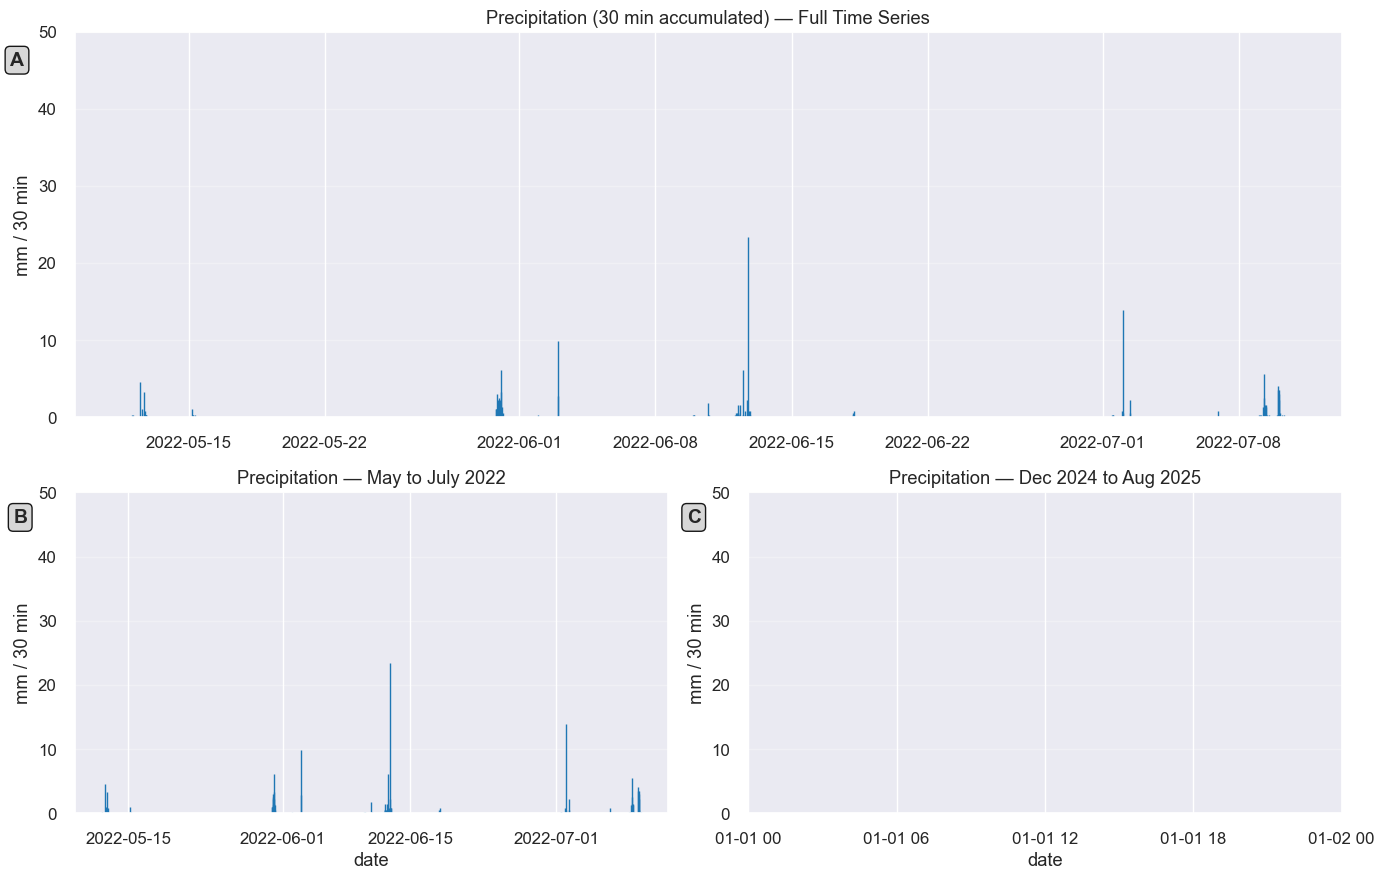

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# ----------------------------
# Time series
# ----------------------------
series = filtered_data.set_index("date_time")["chuva_mm_30min"]

series_valid = series.dropna()
t = series_valid.index
y = series_valid.values

# temporal difference in hours
dt_hours = t.to_series().diff().dt.total_seconds() / 3600
gap_idx = np.where(dt_hours > 6)[0]

# force visual break
y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# chuva só deve ser plotada quando > 0
rain_mask = y_plot > 0

# ----------------------------
# Define zoom windows
# ----------------------------
# 2022 window
zoom_2022_start = pd.Timestamp("2022-05-11 15:30:00")
zoom_2022_end   = pd.Timestamp("2022-07-11 11:00:00")

# 2025 window
zoom_2025_start = pd.Timestamp("2024-12-08 23:00:00")
zoom_2025_end   = pd.Timestamp("2025-08-14 16:00:00")

mask_2022 = (t >= zoom_2022_start) & (t <= zoom_2022_end)
mask_2025 = (t >= zoom_2025_start) & (t <= zoom_2025_end)

# ----------------------------
# Plot layout: A top, B left (2022), C right (2025)
# ----------------------------
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, 0])   # B = 2022
axC = fig.add_subplot(gs[1, 1])   # C = 2025

# ---- A: full period
axA.vlines(
    t[rain_mask],
    0,
    y_plot[rain_mask],
    color="tab:blue",
    linewidth=1.0
)
axA.set_title("Precipitation (30 min accumulated) — Full Time Series")
axA.set_ylabel("mm / 30 min")
axA.set_ylim(0, 50)
axA.grid(axis="y", alpha=0.3)

axA.text(
    -0.04, 0.95, "A",
    transform=axA.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
    bbox=dict(
        facecolor="lightgray",
        edgecolor="black",
        boxstyle="round,pad=0.25",
        alpha=0.9
    )
)

# ---- B: 2022 window
axB.vlines(
    t[mask_2022 & rain_mask],
    0,
    y_plot[mask_2022 & rain_mask],
    color="tab:blue",
    linewidth=1.0
)
axB.set_title("Precipitation — May to July 2022")
axB.set_ylabel("mm / 30 min")
axB.set_xlabel("date")
axB.set_ylim(0, 50)
axB.grid(axis="y", alpha=0.3)
axB.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))

axB.text(
    -0.08, 0.95, "B",
    transform=axB.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
    bbox=dict(
        facecolor="lightgray",
        edgecolor="black",
        boxstyle="round,pad=0.25",
        alpha=0.9
    )
)

# ---- C: 2025 window
axC.vlines(
    t[mask_2025 & rain_mask],
    0,
    y_plot[mask_2025 & rain_mask],
    color="tab:blue",
    linewidth=1.0
)
axC.set_title("Precipitation — Dec 2024 to Aug 2025")
axC.set_ylabel("mm / 30 min")
axC.set_xlabel("date")
axC.set_ylim(0, 50)
axC.grid(axis="y", alpha=0.3)
axC.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))

axC.text(
    -0.08, 0.95, "C",
    transform=axC.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
    bbox=dict(
        facecolor="lightgray",
        edgecolor="black",
        boxstyle="round,pad=0.25",
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()


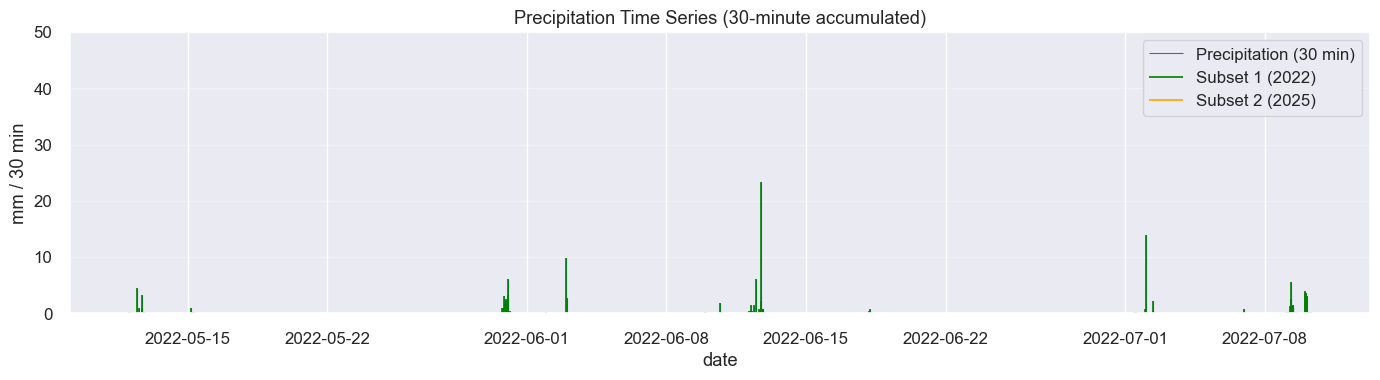

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Time series
# ----------------------------
series = filtered_data.set_index("date_time")["chuva_mm_30min"]

series_valid = series.dropna()
t = series_valid.index
y = series_valid.values

# temporal difference in hours (gap handling)
dt_hours = t.to_series().diff().dt.total_seconds() / 3600
gap_idx = np.where(dt_hours > 6)[0]

y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# plot only rainfall events
rain_mask = y_plot > 0

# ----------------------------
# Define modeling subsets
# ----------------------------
# subset 1 (2022)
subset1_start = pd.Timestamp("2022-05-11 15:30:00")
subset1_end   = pd.Timestamp("2022-07-11 11:00:00")

# subset 2 (2025)
subset2_start = pd.Timestamp("2024-12-08 23:00:00")
subset2_end   = pd.Timestamp("2025-08-14 16:00:00")

mask_subset1 = (t >= subset1_start) & (t <= subset1_end)
mask_subset2 = (t >= subset2_start) & (t <= subset2_end)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(14, 4))

# Full series (background)
ax.vlines(
    t[rain_mask],
    0,
    y_plot[rain_mask],
    color="tab:blue",
    linewidth=0.8,
    label="Precipitation (30 min)"
)

# Subset 1 highlighted (green)
ax.vlines(
    t[rain_mask & mask_subset1],
    0,
    y_plot[rain_mask & mask_subset1],
    color="green",
    linewidth=1.2,
    label="Subset 1 (2022)"
)

# Subset 2 highlighted (orange)
ax.vlines(
    t[rain_mask & mask_subset2],
    0,
    y_plot[rain_mask & mask_subset2],
    color="orange",
    linewidth=1.2,
    label="Subset 2 (2025)"
)

# ----------------------------
# Axis formatting
# ----------------------------
ax.set_title("Precipitation Time Series (30-minute accumulated)")
ax.set_ylabel("mm / 30 min")
ax.set_xlabel("date")
ax.set_ylim(0, 50)
ax.set_yticks(np.arange(0, 51, 10))
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()
